# 02 — Pré-processamento

**Dimensão 4 da rúbrica — 15 pontos.**

Cada decisão precisa de justificativa escrita. Decidir *não* criar features é
aceitável, desde que o motivo esteja explícito.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

from sklearn.preprocessing import OneHotEncoder


# Semente fixa: use em TODO ponto com aleatoriedade (split, modelos, CV).
RANDOM_STATE = 42


PROCESSED = Path("..") / "data" / "processed"
TARGET = Path("..") / "data" / "processed" / "target.csv"    

APPLICATION = Path("..") / "data" / "raw" / "application_record.csv"          
CREDIT = Path("..") / "data" / "raw" / "credit_record.csv" 

MERGE = Path("..") / "data" / "processed" / "application_merge.csv"  

pd.set_option("display.max_columns", None)

In [2]:
credit = pd.read_csv(CREDIT)
application_raw = pd.read_csv(APPLICATION)

## 1. Dados faltantes

In [3]:
nulos = application_raw                                     .isna().sum()
pd.DataFrame({"nulos": nulos, "%": (nulos / len(application_raw) * 100).round(2)}).query("nulos > 0")

,nulos,%
OCCUPATION_TYPE,134203,30.6


In [4]:
application_raw['NAME_INCOME_TYPE'].value_counts().sort_index()

NAME_INCOME_TYPE
Commercial associate    100757
Pensioner                75493
State servant            36186
Student                     17
Working                 226104
Name: count, dtype: int64

In [5]:
#Ajustando a variável OCCUPATION_TYPE, que possui valores nulos, para o valor da variável NAME_INCOME_TYPE, quando OCCUPATION_TYPE for nulo. Caso contrário, mantém o valor original de OCCUPATION_TYPE. Criando uma nova variável chamada OCCUPATION_TYPE_ADJUSTED.
application_raw['OCCUPATION_TYPE_ADJUSTED'] = np.where(application_raw['OCCUPATION_TYPE'].isnull(),application_raw['NAME_INCOME_TYPE'], application_raw['OCCUPATION_TYPE'])

In [6]:
application_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 19 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        438557 non-null  int64  
 1   CODE_GENDER               438557 non-null  str    
 2   FLAG_OWN_CAR              438557 non-null  str    
 3   FLAG_OWN_REALTY           438557 non-null  str    
 4   CNT_CHILDREN              438557 non-null  int64  
 5   AMT_INCOME_TOTAL          438557 non-null  float64
 6   NAME_INCOME_TYPE          438557 non-null  str    
 7   NAME_EDUCATION_TYPE       438557 non-null  str    
 8   NAME_FAMILY_STATUS        438557 non-null  str    
 9   NAME_HOUSING_TYPE         438557 non-null  str    
 10  DAYS_BIRTH                438557 non-null  int64  
 11  DAYS_EMPLOYED             438557 non-null  int64  
 12  FLAG_MOBIL                438557 non-null  int64  
 13  FLAG_WORK_PHONE           438557 non-null  int64  
 14 

Na categoria "OCCUPATION_TYPE", observa-se +30% de dados faltantes. Olhando a categoria "NAME_INCOME_TYPE", nota-se que traz 5 grandes grupos, que podem ser utilizados como substitutos para os dados nulos da categoria "OCCUPATION_TYPE", trazendo uma melhor caracterização do que a simples substituição para "Desconhecido" ("Unknown") ou mesmo a exclusão do cliente do dataset.  Dessa forma, foi criada a coluna "OCCUPATION_TYPE_ADJUSTED", substituindo os valores nulos pelo dado em "NAME_INCOME_TYPE".

## 2. Definição da variável alvo


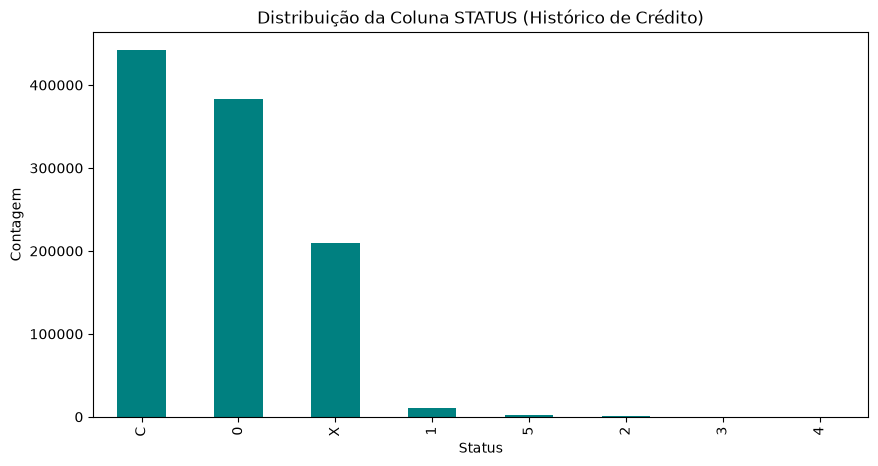


* Distribuição dos Status de Crédito (%):
 STATUS
C    42.16
0    36.54
X    19.95
1     1.06
5     0.16
2     0.08
3     0.03
4     0.02
Name: proportion, dtype: float64


In [7]:
plt.figure(figsize=(10, 5))
credit['STATUS'].value_counts().plot(kind='bar', color='teal')
plt.title('Distribuição da Coluna STATUS (Histórico de Crédito)')
plt.xlabel('Status')
plt.ylabel('Contagem')
plt.show()

# Proporção
print("\n* Distribuição dos Status de Crédito (%):\n",credit['STATUS'].value_counts(normalize=True).round(4)* 100)

Observando a distribuição da categoria 'STATUS', verifica-se uma concentração dos dados no grupo de bons pagadores (C: quitado no mês em análise | X: sem empréstimo no mês em análise). Vale lembrar que essa primeira visualização pode conter dados repetidos para clientes, visto que se trata de histórico de crédito.

In [8]:
#Criação das variáveis TARGET no dataset de crédito
credit['TARGET0'] = credit['STATUS'].apply(lambda x: 1 if x in ['0','1', '2', '3', '4', '5'] else 0)
credit['TARGET1'] = credit['STATUS'].apply(lambda x: 1 if x in ['1', '2', '3', '4', '5'] else 0)
credit['TARGET2'] = credit['STATUS'].apply(lambda x: 1 if x in ['2', '3', '4', '5'] else 0)
credit['TARGET3'] = credit['STATUS'].apply(lambda x: 1 if x in ['3', '4', '5'] else 0)
credit['TARGET4'] = credit['STATUS'].apply(lambda x: 1 if x in ['4', '5'] else 0)
credit['TARGET5'] = credit['STATUS'].apply(lambda x: 1 if x in ['5'] else 0)

target0 = credit.groupby('ID')['TARGET0'].max().reset_index()
target1 = credit.groupby('ID')['TARGET1'].max().reset_index()
target2 = credit.groupby('ID')['TARGET2'].max().reset_index()
target3 = credit.groupby('ID')['TARGET3'].max().reset_index()
target4 = credit.groupby('ID')['TARGET4'].max().reset_index()
target5 = credit.groupby('ID')['TARGET5'].max().reset_index()

pct_targets = pd.DataFrame({
    "Atraso >= 1 dia": target0['TARGET0'].value_counts(normalize=True).round(4) * 100,
    "Atraso >= 30 dias": target1['TARGET1'].value_counts(normalize=True).round(4) * 100,
    "Atraso >= 60 dias": target2['TARGET2'].value_counts(normalize=True).round(4) * 100,
    "Atraso >= 90 dias": target3['TARGET3'].value_counts(normalize=True).round(4) * 100,
    "Atraso >= 120 dias": target4['TARGET4'].value_counts(normalize=True).round(4) * 100,  
    "Atraso >= 150 dias": target5['TARGET5'].value_counts(normalize=True).round(4) * 100  
}).rename(index={0: "bom pagador (0)", 1: "mau pagador (1)"})

print("\n* Quantidade de IDs (clientes) únicos:\n", credit['ID'].nunique())

print("\n* Limiar de atraso:")
display(pct_targets)


* Quantidade de IDs (clientes) únicos:
 45985

* Limiar de atraso:


,Atraso >= 1 dia,Atraso >= 30 dias,Atraso >= 60 dias,Atraso >= 90 dias,Atraso >= 120 dias,Atraso >= 150 dias
bom pagador (0),12.95,88.37,98.55,99.28,99.47,99.58
mau pagador (1),87.05,11.63,1.45,0.72,0.53,0.42


Aqui, é trazida a análise para diversos níveis para a classificação entre bons e maus pagadores, desde o mais rígido (atraso a partir de 1 dia) até o mais flexível (atraso maior ou igual a 150 dias), considerando o pior status de um cliente ao longo de seus registros de crédito. 

Nesse contexto, é possível observar que para atrasos maiores ou iguais a 30 dias, eleva-se a proporção de clientes indicados como bons pagadores. Nesse sentido, quanto mais flexível o nível de atraso, maior a chance de o modelo de aprendizado de máquina indicar como bom pagador um cliente alta chance de inadimplência. 

Por outro lado, atrasos entre 1 e 29 dias não necessariamente representam um risco iminente de inadimplência e quando adotado um critério mais rígido, o modelo de aprendizado de máquina indicar como mau pagador um cliente com baixas chances de inadimplência. 

Dessa forma, para o trabalho de aprendizado de máquina a ser desenvolvido neste projeto, será considerado como risco de aumento de inadimplência clientes com atrasos a partir de 30 dias (categoria 'TARGET1' no dataset 'credit'):
- Mau pagador (TARGET1 = 1): Clientes com algum registro de atraso de 30 dias ou mais (STATUS = 1, 2, 3, 4, 5) em algum mês do histórico de crédito
- Bom pagador (TARGET1 = 0): Clientes sem registro de atraso de 30 dias ou mais (STATUS = 0, C, X) em todos os meses do histórico de crédito



In [9]:
#Cruzamento da base de cadastro com a base de target
application_record = application_raw.drop_duplicates(subset="ID", keep="first")
application_merge = pd.merge(application_record, target1, on='ID', how='inner')
application_merge = application_merge.rename(columns={"TARGET1": "TARGET"})

In [10]:
PROCESSED.mkdir(parents=True, exist_ok=True)
target1.to_csv(PROCESSED / "target.csv", index=False)

In [11]:
df_apoio = pd.merge(application_merge, target0, on='ID', how='inner')
df_apoio = pd.merge(df_apoio, target1, on='ID', how='inner')
df_apoio = pd.merge(df_apoio, target2, on='ID', how='inner')
df_apoio = pd.merge(df_apoio, target3, on='ID', how='inner')
df_apoio = pd.merge(df_apoio, target4, on='ID', how='inner')
df_apoio = pd.merge(df_apoio, target5, on='ID', how='inner')

pct_targets_cross = pd.DataFrame({
    "Atraso >= 1 dia": df_apoio['TARGET0'].value_counts(normalize=True).round(4) * 100,
    "Atraso >= 30 dias": df_apoio['TARGET1'].value_counts(normalize=True).round(4) * 100,
    "Atraso >= 60 dias": df_apoio['TARGET2'].value_counts(normalize=True).round(4) * 100,
    "Atraso >= 90 dias": df_apoio['TARGET3'].value_counts(normalize=True).round(4) * 100,
    "Atraso >= 120 dias": df_apoio['TARGET4'].value_counts(normalize=True).round(4) * 100,  
    "Atraso >= 150 dias": df_apoio['TARGET5'].value_counts(normalize=True).round(4) * 100  
}).rename(index={0: "bom pagador (0)", 1: "mau pagador (1)"})



In [12]:
print("\n* Quantidade de clientes únicos com cadastro ANTES do cruzamento:\n", application_raw['ID'].nunique())

print("\n* Quantidade clientes únicos com histórico de crédito:\n", credit['ID'].nunique())

print("\n* Quantidade de clientes únicos com cadastro APÓS o cruzamento:\n", application_merge['ID'].nunique())

print("\n* Clientes descartados da análise, com registro de crédito e sem cadastro:\n", credit['ID'].nunique() - application_merge['ID'].nunique())

print("\n* Clientes descartados da análise, sem registro de crédito e com cadastro:\n", application_raw['ID'].nunique() - application_merge['ID'].nunique())

print("\n* Limiar de atraso (após merge com application_merge):")
display(pct_targets_cross)



* Quantidade de clientes únicos com cadastro ANTES do cruzamento:
 438510

* Quantidade clientes únicos com histórico de crédito:
 45985

* Quantidade de clientes únicos com cadastro APÓS o cruzamento:
 36457

* Clientes descartados da análise, com registro de crédito e sem cadastro:
 9528

* Clientes descartados da análise, sem registro de crédito e com cadastro:
 402053

* Limiar de atraso (após merge com application_merge):


,Atraso >= 1 dia,Atraso >= 30 dias,Atraso >= 60 dias,Atraso >= 90 dias,Atraso >= 120 dias,Atraso >= 150 dias
bom pagador (0),12.22,88.23,98.31,99.17,99.38,99.51
mau pagador (1),87.78,11.77,1.69,0.83,0.62,0.49


Foi realizado o cruzamento da base de cadastro (application) com os targets no registro de crédito (credit). Seguem os pontos de destaque:
- Do universo de 438510 clientes, apenas 36457 têm cadastro e histórico de crédito, ou seja, são ~8% de dados completos para modelagem.
- Observando os níveis de atraso após o cruzamento dos dados se mantém similar com o que foi visto no dataset credit.
- Nota-se em todos os níveis de atraso um desbalanceamento das classes. 

## 3. Normalização / padronização

No que se refere à normalização/padronização, será aplicada conforme o algoritmo a ser utilizado:
- Nos modelos lineares (como SVM) ou baseados em distância (como o KNN), será utilizada a técnica de padronização das variáveis com o StandardScaler da biblioteca Sklearn.
- Nos modelos baseados em árvores de decisão (como o Random Forest), não há necessidade de se aplicar técnicas normalização ou padronização, visto que não são sensíveis às escalas das variáveis

## 4. Feature engineering

Ainda na etapa da análise exploratória dos dados, foi necessário atualizar algumas categorias para se seguir com o estudo. As atualizações são elencadas a seguir: 

- Ajuste das variáveis DAYS_BIRTH e DAYS_EMPLOYED para anos, criando novas variáveis YEARS_BIRTH e YEARS_EMPLOYED
- Adição da variável FLAG_UNEMPLOYED, que indica se o cliente está desempregado (1) ou não (0), com base na variável DAYS_EMPLOYED (se DAYS_EMPLOYED >= 0, então o cliente está desempregado)
- Utilização da técnica de label encoding, convertendo as variáveis CODE_GENDER, FLAG_OWN_CAR, FLAG_OWN_REALTY, NAME_EDUCATION_TYPE_NUM de string para int
- Utilização da técnica one hot encoding para as categorias OCCUPATION_TYPE_GROUPED, NAME_FAMILY_STATUS, NAME_HOUSING_TYPE, para binarização.

In [13]:
#Ajustando as variáveis DAYS_BIRTH e DAYS_EMPLOYED para anos, criando novas variáveis YEARS_BIRTH e YEARS_EMPLOYED
application_merge['YEARS_BIRTH'] = abs(application_merge['DAYS_BIRTH']) / 365

application_merge['YEARS_EMPLOYED'] = np.where(application_merge['DAYS_EMPLOYED'] < 0,abs(application_merge['DAYS_EMPLOYED']) / 365, 0)

#Adicionando a variável "FLAG_UNEMPLOYED", que indica se o cliente está desempregado (1) ou não (0), com base na variável DAYS_EMPLOYED.
application_merge['FLAG_UNEMPLOYED'] = np.where(application_merge['DAYS_EMPLOYED'] < 0, 0, 1)

#Ajustandando as variáveis binárias de str para int
application_merge['CODE_GENDER_DUMMY'] = np.where(application_merge['CODE_GENDER'] == 'F', 0, 1)
application_merge['FLAG_OWN_CAR_DUMMY'] = np.where(application_merge['FLAG_OWN_CAR'] == 'Y', 1, 0)
application_merge['FLAG_OWN_REALTY_DUMMY'] = np.where(application_merge['FLAG_OWN_REALTY'] == 'Y', 1, 0)

#Ajustando a variável NAME_EDUCATION_TYPE para valores numéricos
application_merge['NAME_EDUCATION_TYPE_NUM'] = application_merge['NAME_EDUCATION_TYPE'].map(
{   'Lower secondary': 1,
    'Secondary / secondary special': 2,
    'Incomplete higher': 3,
    'Higher education': 4,
    'Academic degree': 5
}
)



In [14]:
application_merge['OCCUPATION_TYPE_ADJUSTED'].value_counts(normalize=True).round(4) * 100

OCCUPATION_TYPE_ADJUSTED
Laborers                 17.04
Pensioner                16.84
Core staff                9.85
Sales staff               9.56
Working                   8.77
Managers                  8.26
Drivers                   5.86
Commercial associate      3.94
High skill tech staff     3.79
Accountants               3.40
Medicine staff            3.31
Cooking staff             1.80
Security staff            1.62
Cleaning staff            1.51
State servant             1.50
Private service staff     0.94
Low-skill Laborers        0.48
Waiters/barmen staff      0.48
Secretaries               0.41
HR staff                  0.23
Realty agents             0.22
IT staff                  0.16
Student                   0.00
Name: proportion, dtype: float64

Olhando a distribuição das profissões, observa-se que as 8 primeiras concentram 80% dos clientes, seguindo princípio de Pareto. Dessa forma, vamos fazer ajustes nessas coluna e aplicar a técnica de one hot encoding, transformando as variáveis categócias em valores numéricos.

In [15]:
#Agrupando profissisões para aplicação da técnica de one-hot encoding.
professions = [
    "Laborers",
    "Pensioner",
    "Core staff",
    "Sales staff",
    "Working",
    "Managers",
    "Drivers",
    "Commercial associate"
]

application_merge['OCCUPATION_TYPE_GROUPED'] = np.where(
    application_merge['OCCUPATION_TYPE_ADJUSTED'].isin(professions),
    application_merge['OCCUPATION_TYPE_ADJUSTED'],
    "Others"
)



In [16]:
#colunas a serem convertidas em variáveis dummy (one-hot encoding)
from sklearn.preprocessing import OneHotEncoder

cols_one_hot = ['OCCUPATION_TYPE_GROUPED', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE']

ohe = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False,
    drop='first'  
)

encoded_array = ohe.fit_transform(application_merge[cols_one_hot])

encoded_df = pd.DataFrame(
    encoded_array,
    columns=ohe.get_feature_names_out(cols_one_hot),
    index=application_merge.index
)

application_merge = pd.concat([application_merge, encoded_df], axis=1)

print(f"Total de novas colunas criadas: {encoded_df.shape[1]}")



Total de novas colunas criadas: 17


In [17]:
application_merge.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
ID,36457.0,5078227.00,41875.24,5008804.00,5042028.00,5074614.00,5115396.00,5150487.00
CNT_CHILDREN,36457.0,0.43,0.74,0.00,0.00,0.00,1.00,19.00
AMT_INCOME_TOTAL,36457.0,186685.74,101789.23,27000.00,121500.00,157500.00,225000.00,1575000.00
DAYS_BIRTH,36457.0,-15975.17,4200.55,-25152.00,-19438.00,-15563.00,-12462.00,-7489.00
DAYS_EMPLOYED,36457.0,59262.94,137651.33,-15713.00,-3153.00,-1552.00,-408.00,365243.00
FLAG_MOBIL,36457.0,1.00,0.00,1.00,1.00,1.00,1.00,1.00
FLAG_WORK_PHONE,36457.0,0.23,0.42,0.00,0.00,0.00,0.00,1.00
FLAG_PHONE,36457.0,0.29,0.46,0.00,0.00,0.00,1.00,1.00
FLAG_EMAIL,36457.0,0.09,0.29,0.00,0.00,0.00,0.00,1.00
CNT_FAM_MEMBERS,36457.0,2.20,0.91,1.00,2.00,2.00,3.00,20.00


In [18]:
application_merge.info()

<class 'pandas.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 45 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   ID                                       36457 non-null  int64  
 1   CODE_GENDER                              36457 non-null  str    
 2   FLAG_OWN_CAR                             36457 non-null  str    
 3   FLAG_OWN_REALTY                          36457 non-null  str    
 4   CNT_CHILDREN                             36457 non-null  int64  
 5   AMT_INCOME_TOTAL                         36457 non-null  float64
 6   NAME_INCOME_TYPE                         36457 non-null  str    
 7   NAME_EDUCATION_TYPE                      36457 non-null  str    
 8   NAME_FAMILY_STATUS                       36457 non-null  str    
 9   NAME_HOUSING_TYPE                        36457 non-null  str    
 10  DAYS_BIRTH                               36457 non-null  

## 5. Salvar dataset tratado

In [19]:
application_final = application_merge.drop(columns=[
    'CODE_GENDER', 
    'FLAG_OWN_CAR', 
    'FLAG_OWN_REALTY', 
    'FLAG_MOBIL', 
    'CNT_CHILDREN',
    'FLAG_UNEMPLOYED',
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS', 
    'NAME_HOUSING_TYPE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'OCCUPATION_TYPE',
    'OCCUPATION_TYPE_ADJUSTED',
    'OCCUPATION_TYPE_GROUPED'                                                       
    ])

application_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 30 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   ID                                       36457 non-null  int64  
 1   AMT_INCOME_TOTAL                         36457 non-null  float64
 2   FLAG_WORK_PHONE                          36457 non-null  int64  
 3   FLAG_PHONE                               36457 non-null  int64  
 4   FLAG_EMAIL                               36457 non-null  int64  
 5   CNT_FAM_MEMBERS                          36457 non-null  float64
 6   TARGET                                   36457 non-null  int64  
 7   YEARS_BIRTH                              36457 non-null  float64
 8   YEARS_EMPLOYED                           36457 non-null  float64
 9   CODE_GENDER_DUMMY                        36457 non-null  int64  
 10  FLAG_OWN_CAR_DUMMY                       36457 non-null  

Aqui, optou-se por excluir as categorias tipo string e as colunas redundantes DAYS_BIRTH e DAYS_EMPLOYED, buscando deixar o dataset mais leve antes de finalizar o processamento.


In [20]:
PROCESSED.mkdir(parents=True, exist_ok=True)
application_final.to_csv(PROCESSED / "dataset_tratado.csv", index=False)